# MES (Micro E-mini S&P 500) — MA crossover, Tradovate exchange

Mirrors `test_backtester.ipynb`'s MA-crossover setup, but trades **Micro ES futures**
through a simulated **Tradovate** exchange instead of spot ETH/USD through a crypto
exchange: real 1h OHLC resampled locally from Databento's full-history 1-minute
MES continuous-contract Parquet file (`data_aggregator.databento_aggregator`,
GLBX.MDP3, `MES.c.0`) instead of the Mongo/Timescale IB feed or a CSV, whole-contract
position sizing, tick-based slippage + per-contract fees, and a Tradeify-style
EOD-trailing drawdown risk middleware.

**Strategy**: a single KAMA(fast)/session-VWAP(slow) crossover -- KAMA(34)
against session VWAP (`Indicators.vwap_session`), the challenger found in
`step_1_find_best_indicators_and_parameters.ipynb`'s Experiments 6-7 (KAMA vs.
session VWAP, both orderings), which beat the previous KAMA/SMA(132/42) pick on
`trade_sharpe_lb` (+0.575 vs. +0.554) and held up well out-of-sample (test-slice
Sharpe *higher* than train, drawdown less than half of train's -- see that
notebook's "Final pick" cell for the full numbers). **Trades far more often**
(~114/year vs. ~22/year for the previous pick) and has a wider frictionless
drawdown (-25.6% vs. -13.6%) -- this run is specifically to see whether that
higher turnover/drawdown profile holds up, gets worse, or gets better once real
position sizing, margin, and the Tradeify drawdown middleware are modeled, the
same question the previous pick was already put through (see git history / prior
notebook state for that comparison run if useful). Session VWAP has no length of
its own (anchored to each session's start, not a rolling window) and resets at
every UTC-midnight boundary -- see that indicator's own docstring for the known
session-boundary simplification (real CME session boundary is ~17:00 Chicago
time, not UTC midnight). Run through the full event-driven engine: real order
fills, margin, whole-contract sizing, and the drawdown middleware, none of which
the vectorized notebook models. Like that notebook, this run uses the full range
Databento actually has for MES's continuous contract (2019-05-05 onward, the
contract's real launch date, through whenever the Parquet was last downloaded),
rather than a fixed `DATE_FROM`/`DATE_TO` window -- results here will still differ
from that notebook's frictionless vectorized numbers even with the same
parameters and data, since whole-contract sizing/margin are modeled for real here
instead of as a frictionless percentage-return approximation.

**Costs, now researched** (`PROP_FIRM_PLAN.md`, `OPTIMIZATION_RESEARCH_PLAN.md`): MES
tick_size=0.25 index points ($1.25/tick, CME spec) and a $0.91/side commission (half
of Tradeify's $1.82 MES round-turn) are set directly on `TRADOVATE_FUTURES["MES"]` in
`exchange_config.py` -- the earlier `slippage_ticks=0`/`default_fee_per_contract=0.0`
placeholder overrides are gone. The drawdown middleware below also uses Tradeify's
real $50k-Growth-account number (4%, not this middleware's generic 5% default).

In [1]:
import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/tradovate_ma_crossover/MES


In [2]:

# Instantiate markets class
market = Market()

# ALL INTERVALS SHOULD BE THE SAME!!
INTERVAL = 1
UNIT_OF_TIME = "hour"

DISPLAY_SYMBOL = "MES"       # bare symbol
SYMBOL = "MES/USD"           # backtester-internal symbol (asset/quote)

# Full available history from Databento's MES continuous front-month contract
# (GLBX.MDP3, MES.c.0), downloaded once as 1-minute OHLCV via
# data_aggregator.databento_aggregator.confirm_and_download() (~$9, one-time cost) and
# resampled to 1h bars here -- not sliced to a fixed DATE_FROM/DATE_TO window like the
# Mongo/Timescale-backed version of this notebook, since the point of this pass is to
# see the strategy over as much real history as we actually have on file.
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- plain
    # `jupyter nbconvert` uses the notebook's own directory, VS Code's Jupyter
    # extension uses the workspace root, etc. Rather than assume a fixed number of
    # parent hops (which broke under VS Code), walk upward until the target actually
    # exists -- works under any of them since the repo root is always some ancestor
    # of cwd.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


PARQUET_PATH = _find_upwards(
    "apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd)
)

# Challenger from step_1_find_best_indicators_and_parameters.ipynb's
# Experiments 6-7 (KAMA vs. session VWAP, both orderings, added after the
# original 4/5-indicator-family comparison): KAMA(fast)/session-VWAP(slow),
# KAMA length=34 -- beat the previous KAMA/SMA(132/42) pick on trade_sharpe_lb
# (+0.575 vs +0.554) and held up well out-of-sample (test-slice Sharpe higher
# than train, drawdown less than half of train's). KAMA's own fast/slow EMA
# constants are left at Kaufman's defaults (2, 30), same as the previous pick --
# not re-tuned for this specific pairing. Session VWAP has no length of its own
# (see Indicators.vwap_session's docstring for the UTC-midnight session-boundary
# simplification) -- computed once below from the same `ohlc` used everywhere
# else in this notebook.
KAMA_FAST_LEN = 34
KAMA_EMA_FAST = 2
KAMA_EMA_SLOW = 30

ohlc = load_1m_parquet_resampled(PARQUET_PATH, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)

market.add_market(
    symbol=SYMBOL,
    df=ohlc
    )

# --- KAMA(fast)/session-VWAP(slow) crossover indicators -- only 2, one per side.
KAMA_INDICATOR_NAME = 'kama'
VWAP_INDICATOR_NAME = 'vwap_session'
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{KAMA_INDICATOR_NAME}_{KAMA_FAST_LEN}",
    df=Indicators.kama(ohlc, length=KAMA_FAST_LEN, fast=KAMA_EMA_FAST, slow=KAMA_EMA_SLOW)
)
_vwap_session_series, _vwap_session_std = Indicators.vwap_session(ohlc)
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=VWAP_INDICATOR_NAME,
    df=_vwap_session_series,
)

market.compile()

{Timestamp('2019-05-05 22:59:59.999000'): {'num': 0,
  'time_open': Timestamp('2019-05-05 22:00:00'),
  'time_close': Timestamp('2019-05-05 22:59:59.999000'),
  'MES/USD': {'open': 2925.75,
   'high': 2926.75,
   'low': 2894.75,
   'close': 2908.5,
   'volume': 202,
   'indicators': {'kama_34': nan, 'vwap_session': 2910.0}}},
 Timestamp('2019-05-05 23:59:59.999000'): {'num': 1,
  'time_open': Timestamp('2019-05-05 23:00:00'),
  'time_close': Timestamp('2019-05-05 23:59:59.999000'),
  'MES/USD': {'open': 2909.0,
   'high': 2909.0,
   'low': 2892.75,
   'close': 2893.75,
   'volume': 585,
   'indicators': {'kama_34': nan, 'vwap_session': 2901.451715374841}}},
 Timestamp('2019-05-06 00:59:59.999000'): {'num': 2,
  'time_open': Timestamp('2019-05-06 00:00:00'),
  'time_close': Timestamp('2019-05-06 00:59:59.999000'),
  'MES/USD': {'open': 2895.25,
   'high': 2900.0,
   'low': 2888.0,
   'close': 2888.0,
   'volume': 1324,
   'indicators': {'kama_34': nan, 'vwap_session': 2892.0}}},
 Timest

In [3]:

# single KAMA(fast)/session-VWAP(slow) crossover strategy, full weight -- see
# step_1_find_best_indicators_and_parameters.ipynb's Experiments 6-7 for how this
# challenger was found (beat the previous KAMA/SMA(132/42) pick on trade_sharpe_lb
# and held up well out-of-sample).
#
# sl_percent/tp_percent are fractional distances from entry (sl_percent=0.3 means the
# stop sits 30% below entry, not 0.3%). Left unchanged from the previous KAMA/SMA
# pick's values here -- this run isolates the crossover-pair change alone -- but that
# reasoning was explicitly sized around KAMA/SMA's ~8-10 day average hold; this
# candidate trades ~5x more often (~114/year vs ~22/year), so its real average
# holding period is presumably much shorter and these values haven't been re-derived
# for it. Worth revisiting with its own excursion analysis if this candidate is kept.
portfolio = Portfolio(weighted_strategies=[
    WeightedStrategy(
        weight=1.0,
        strategy=MaCrossoverStrategy(
            key="KAMA_34_VWAP_MES",
            market=market,
            symbol=SYMBOL,
            direction=StrategyDirection.long,
            fast_indicator_key=f"{KAMA_INDICATOR_NAME}_{KAMA_FAST_LEN}",
            slow_indicator_key=VWAP_INDICATOR_NAME,
            sl_percent=0.025,
            tp_percent=0.07,
            sl_enabled=True,
            tp_enabled=True,
        ),
    ),
], output_scale=1)

print("Portfolio is ready!")


Portfolio is ready!


In [4]:

# Tradovate per-symbol config: point value / tick size / min size-step / fees.
# MES now has a real tick_size (0.25 pts) and fee_per_contract_override ($0.91/side)
# set directly on TRADOVATE_FUTURES in exchange_config.py -- no override needed here
# anymore (see PROP_FIRM_PLAN.md for the research).
symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)

# instantiate exchange -- futures, point-value/tick-based math via symbol_config_provider
# (slippage/maker_fee/taker_fee below are unused once symbol_config_provider is set, but
# still required constructor args).
exchange = Exchange(
            market=market,
            slippage=0.0,
            maker_fee=0.0,
            taker_fee=0.0,
            market_type=MarketType.future,
            max_leverage=10,  # NOTE: this system doesn't model Tradovate's real per-symbol
                               # exchange-set margin schedule yet -- max_leverage is a stand-in.
            margin_allocation_type=MarginAllocationType.cross,
            symbol_config_provider=symbol_config_provider,
        )


In [5]:

# instantiate reporter
# periods_per_year=252: real trading-days/year convention for futures (not 365,
# which is only correct for a 24/7 crypto market -- see PerformanceAnalyzer's own
# docstring). Using the wrong constant here previously inflated every Sharpe/
# Sortino/annualized-volatility number in this pipeline by sqrt(365/252) =~ 1.20
# (~20%) versus the correct figure -- CAGR/Calmar/max_drawdown/net_return are
# unaffected since they don't depend on periods_per_year.
reporter = PerformanceAnalyzer(market=market,
                    exchange=exchange,
                    portfolio=portfolio,
                    benchmark_symbols=[SYMBOL],
                    periods_per_year=252)


Candles Processed:  42239
Account failed (drawdown breach):  False
Drawdown floor locked (reached profit buffer):  True


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.8444,0.8488,0.9733,0.4584,-0.0514,1.7480,0.9526,1.3715,1.1617,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,1.3160,1.1738,1.5431,0.6256,-0.0726,2.7624,1.3603,3.0564,1.7184,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,8.6894,6.8277,12.4904,6.0869,11.0433,6.4099,5.8546,9.8509,6.8986,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,10.6086,8.3896,17.9747,3.8565,-1.6928,17.3192,8.1670,20.8417,11.9879,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.9299,1.8496,1.6695,0.6493,-0.1484,3.2429,2.2503,4.1133,3.1394,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,9.3356,1.1993,1.6695,0.6475,-0.1480,3.2332,2.2503,4.1009,1.6071,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-11.4079,-4.5360,-10.7662,-5.9393,-11.4079,-5.3407,-3.6294,-5.0669,-3.8186,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,348,92,101,222,336,139,63,45,50,719,How long it took to recover the loss. Shorter is better.
ulcer_index,3.0642,1.1757,3.3977,2.0721,6.4038,1.8144,1.0539,1.4060,1.4981,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.7967,-0.5529,-1.0857,-0.6033,-1.2077,-0.6421,-0.6292,-0.7054,-0.5945,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


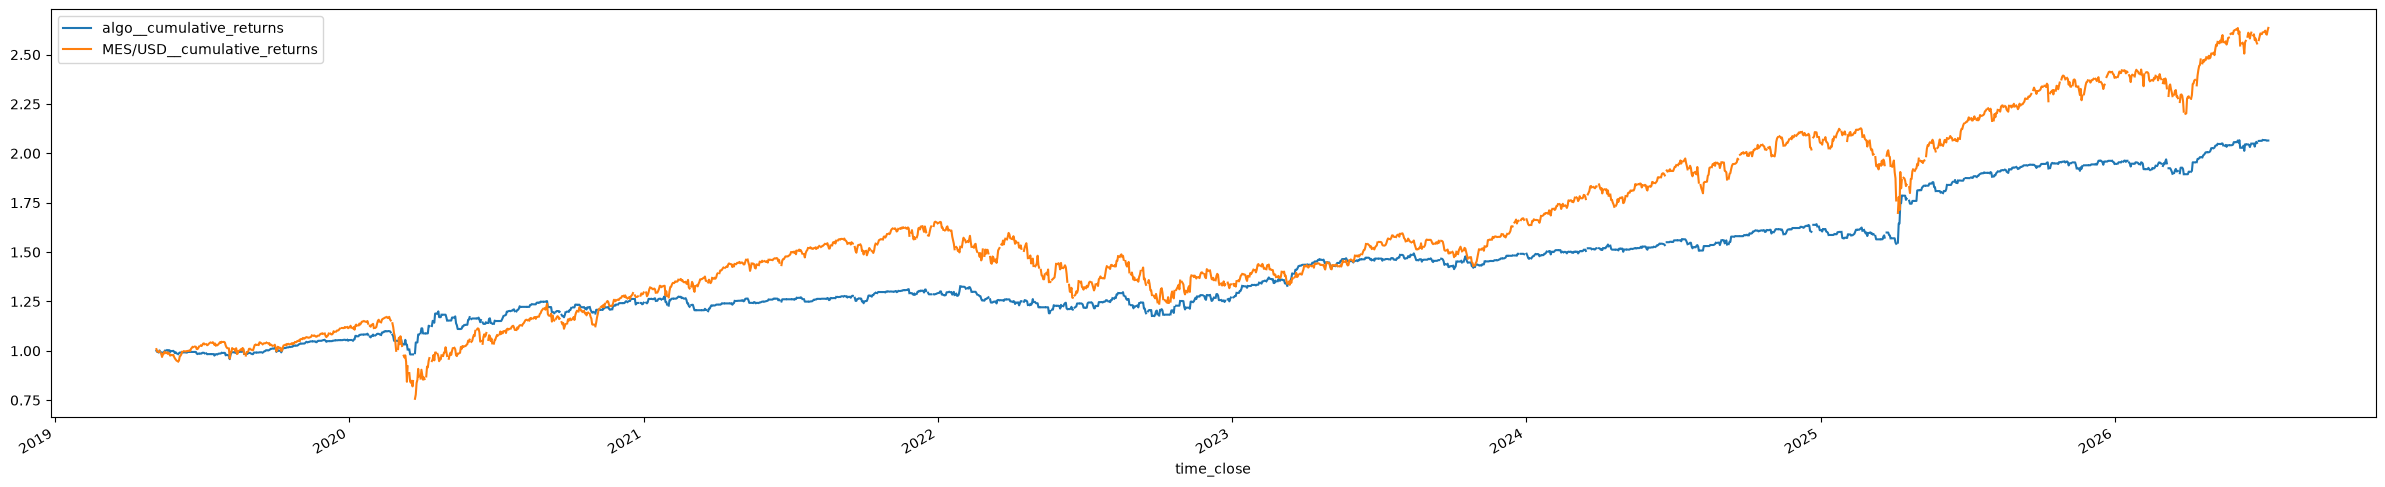

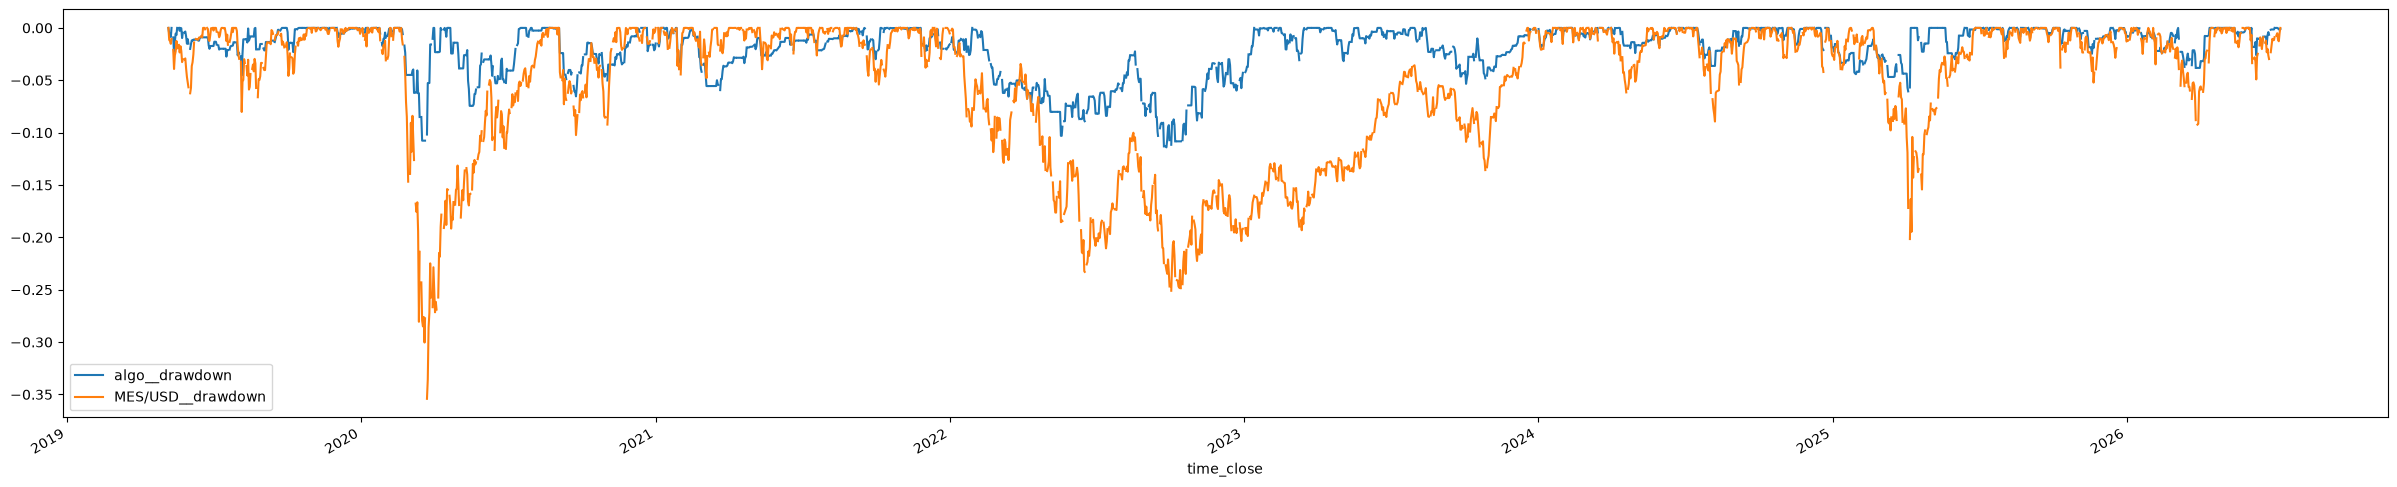

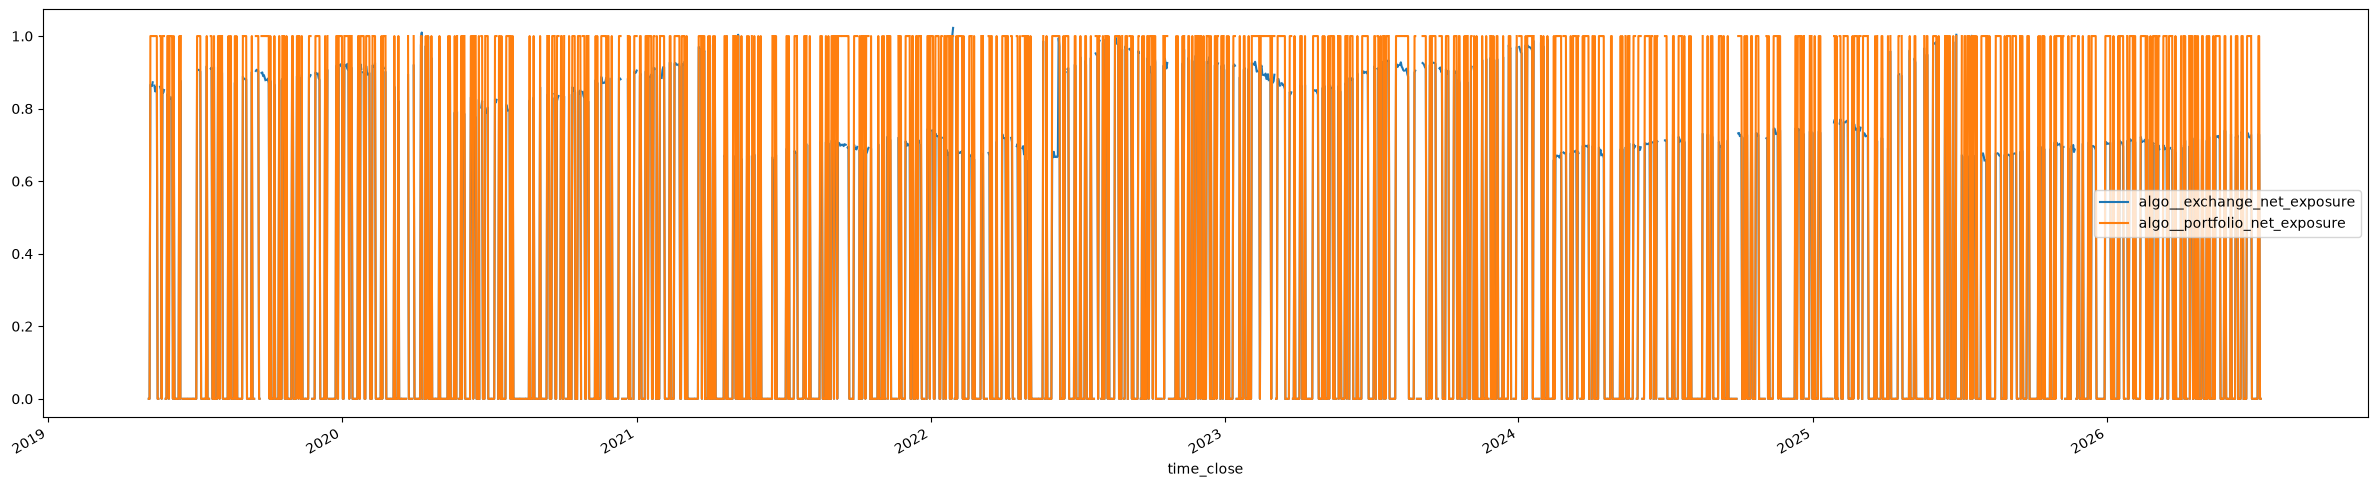

In [6]:

# run only one next step
market.reset()

# Tradeify's real $50k Growth account limits are $2,000 (4%) EOD-trailing drawdown
# and a $1,250/day (2.5%) soft daily-loss pause -- see middleware.py / PROP_FIRM_PLAN.md.
# Deliberately loosened to 50%/50% here instead of the real 0.04/0.025: this notebook
# tests ONE strategy sleeve in isolation, but the real Tradeify limits apply at the
# whole-account level once multiple strategies are combined and each only gets a
# fraction of the $50k -- enforcing the full-account limit against a single sleeve's
# 100%-of-capital test run halts it on drawdown that a properly-sized fraction
# wouldn't actually reach. Loosened here so the full trade history/equity curve is
# visible for this sleeve; re-tighten to 0.04/0.025 (or whatever this strategy's
# actual capital allocation implies) once it's combined with others.
drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)

backtest = Backtester(
    market=market,
    portfolio=portfolio,
    exchange=exchange,
    reporter=reporter,
    middlewares=[daily_loss_middleware, drawdown_middleware],
)
# deposit prop-firm-sized funds so we can trade
backtest.exchange.transactions.add_deposit(asset="USD", volume=50000)
backtest.run_all()

# Print Report
print("Candles Processed: ", backtest.market.current['num'])
print("Account failed (drawdown breach): ", drawdown_middleware.account_failed)
print("Drawdown floor locked (reached profit buffer): ", drawdown_middleware.locked)

# Year-by-year (or quarter-by-quarter) performance split, alongside the usual
# whole-period "algo" column -- e.g. algo, algo_2024, algo_2025, ..., then the
# benchmark column as before. "Y" = calendar year, "Q" = calendar quarter, None =
# original single-column table (set below to change; see
# PerformanceAnalyzer.summary_html_table's docstring for the full behavior).
PERFORMANCE_SPLIT = "Y"

# formatted HTML table (description column + color-coded cells) instead of the raw
# numeric DataFrame -- see backtester.performance.report_html for the per-metric rules.
display(HTML(backtest.reporter.summary_html_table(split=PERFORMANCE_SPLIT)))

if backtest.reporter.merged is not None:
    # Print a chart to compare the returns
    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure"
        ], figsize=(30,6))


In [7]:
# market.merged
pd.DataFrame(backtest.exchange.get_logs())


,time,message
0,2019-05-05 23:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1,2019-05-07 13:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
2,2019-05-10 00:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
3,2019-05-10 03:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
4,2019-05-15 00:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
...,...,...
1638,2026-06-29 03:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1639,2026-07-03 00:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1640,2026-07-03 01:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1641,2026-07-07 14:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...


In [8]:
# get dataframe with all the trades that were executed
def _trade_to_dict(trade):
    d = trade.__dict__.copy()
    for k, v in d.items():
        if hasattr(v, "value"):
            d[k] = v.value
    return d

pd.DataFrame([_trade_to_dict(t) for t in backtest.reporter.trades])


,symbol,side,time_open,time_close,open_price,close_price,close_reason,pnl,result,holding_period,risk_percent
0,MES/USD,long,1557237599999000000,1557449999999000000,2902.50,2879.00,signal,-0.008096,loser,212400000000000,0.025
1,MES/USD,long,1557460799999000000,1557881999999000000,2859.75,2838.00,signal,-0.007606,loser,421200000000000,0.025
2,MES/USD,long,1557925199999000000,1557950399999000000,2820.50,2853.00,signal,0.011523,winner,25200000000000,0.025
3,MES/USD,long,1557964799999000000,1557968399999000000,2852.25,2848.50,signal,-0.001315,loser,3600000000000,0.025
4,MES/USD,long,1558097999999000000,1558105199999000000,2858.00,2882.50,signal,0.008572,winner,7200000000000,0.025
...,...,...,...,...,...,...,...,...,...,...,...
816,MES/USD,long,1782179999999000000,1782316799999000000,7522.50,7480.25,signal,-0.005616,loser,136800000000000,0.025
817,MES/USD,long,1782323999999000000,1782367199999000000,7414.00,7472.00,signal,0.007823,winner,43200000000000,0.025
818,MES/USD,long,1782395999999000000,1782705599999000000,7393.00,7450.25,signal,0.007744,winner,309600000000000,0.025
819,MES/USD,long,1783040399999000000,1783043999999000000,7530.00,7549.25,signal,0.002556,winner,3600000000000,0.025
